# DESY3 X-ray bright groups: $L_{\rm{X}}$-$\lambda_{\rm{RM}}$

This section of the project <span style='color:red'>**...**</span>

## Import Statements

In [1]:
import pandas as pd
pd.set_option('display.max_columns', 500)
import numpy as np
from astropy.units import Quantity
from astropy.cosmology import LambdaCDM
import os
from matplotlib import pyplot as plt
from matplotlib.ticker import FuncFormatter

# This adds the directory above to the path, allowing me to import the common functions that I've written in
#  common.py - this just saves me repeating boring code and makes sure its all consistent
import sys
sys.path.insert(0, '..')
from common import cosmo

## Output paths

In [2]:
gen_fig_out_path = "../../outputs/figures/results_analyses/lx_richness/"
os.makedirs(gen_fig_out_path, exist_ok=True)

## Cosmological model

In [3]:
cosmo

LambdaCDM(name=None, H0=<Quantity 70. km / (Mpc s)>, Om0=0.3, Ode0=0.7, Tcmb0=<Quantity 0. K>, Neff=3.04, m_nu=None, Ob0=0.0)

## Loading data files

Important considerations for these datasets:

* <span style='color:red'>**...**</span>

### DESY3RM base sample

In [4]:
desy3rm_groups_base = pd.read_csv("../../sample_files/DESY3RM_richlte20_zlte03_noupload.csv")
desy3rm_groups_base = desy3rm_groups_base[['name', 'LAMBDA_CHISQ', 'LAMBDA_CHISQ_E']]
desy3rm_groups_base = desy3rm_groups_base.rename(columns={'LAMBDA_CHISQ': 'richness', 'LAMBDA_CHISQ_E': 'richness_err'})
desy3rm_groups_base.head(6)

,name,richness,richness_err
0,DESY3RM-27,5.953653,2.425779
1,DESY3RM-124,6.411303,2.821462
2,DESY3RM-880,7.052011,2.911375
3,DESY3RM-1850,6.960482,2.249001
4,DESY3RM-1882,5.251925,2.284099
5,DESY3RM-2108,5.358709,2.826117


### DESY3RM-XMM galaxy group $L_{\rm{X}}$ and $T_{\rm{X}}$ results

In [5]:
desy3rm_groups_lxtx = pd.read_csv("../../outputs/result_files/xga_ltr/XGA-LTR_r500_pipeline_radconverged_joined.csv")
# TODO PUT THIS ELSEWHERE, WANT THE STORED RESULTS FILE FORMATTED LIKE THIS
desy3rm_groups_lxtx = desy3rm_groups_lxtx.rename(columns={'Lx500_0.5-2.0': 'Lx52_500', 'Lx500_0.5-2.0-': 'Lx52_500-', 
                                                          'Lx500_0.5-2.0+': 'Lx52_500+', 'Tx500': 'Tx_500', 
                                                          'Tx500-': 'Tx_500-', 'Tx500+': 'Tx_500+'})
desy3rm_groups_lxtx.head(6)

,name,ra,dec,redshift,nH,r500,r500+-,Tx_500,Tx_500-,Tx_500+,Lx52_500,Lx52_500-,Lx52_500+,Lx500_0.01-100.0,Lx500_0.01-100.0-,Lx500_0.01-100.0+,Tx500ce,Tx500ce-,Tx500ce+,Lx500ce_0.5-2.0,Lx500ce_0.5-2.0-,Lx500ce_0.5-2.0+,Lx500ce_0.01-100.0,Lx500ce_0.01-100.0-,Lx500ce_0.01-100.0+,radstep0,radstep1,radstep2,radstep3,radstep4,radstep5,radstep6,radstep7,radstep8,radstep9,radstep10,rad_converged,MEM_MATCH_ID,REFMAG,REFMAG_ERR,ZRED,ZRED_E,ZRED_CHISQ,BCG_SPEC_Z,Z_SPEC_INIT,Z_INIT,Z,LAMBDA_CHISQ,LAMBDA_CHISQ_E,LAMBDA_ZRED,LAMBDA_ZRED_E,R_LAMBDA,SCALEVAL,MASKFRAC,GEOMASKFRAC,CHISQ,Z_LAMBDA,Z_LAMBDA_E,Z_LAMBDA_NITER,EBV_MEAN,LNLAMLIKE,LNBCGLIKE,LNLIKE,NCROSS,RMASK,RA_ORIG,DEC_ORIG,W,DLAMBDA_DZ,DLAMBDA_DZ2,DLAMBDAVAR_DZ,DLAMBDAVAR_DZ2,LAMBDA_CHISQ_C,LAMBDA_CHISQ_CE,NCENT,NCENT_GOOD,Q_MISS,BCG_ILUM,ILUM,Z_LAMBDA_RAW,Z_LAMBDA_E_RAW,LIM_EXPTIME,LIM_LIMMAG_DERED,LIM_LIMMAG,LIM_LIMMAG_HARD,MASKGAL_INDEX
0,DESY3RM-27,323.831479,1.484002,0.228469,0.0384,1332.431437,81.266701,9.622885,1.369100,1.732226,6.434168e+43,2.701511e+42,2.786899e+42,2.864291e+44,2.202990e+43,2.188908e+43,10.289737,1.698929,2.003489,5.923744e+43,2.823887e+42,2.789864e+42,2.717689e+44,2.328472e+43,1.647037e+43,500.0,944.882917,1331.096319,1440.758919,1332.431437,1332.431437,1332.431437,1332.431437,1332.431437,1332.431437,1332.431437,True,27,17.643797,0.004119,0.212444,0.016494,15.878660,-1.000000,-1.0,0.302381,0.237442,5.953653,2.425779,9.035158,2.340376,0.568796,1.024119,0.020880,0.0,16.485155,0.228469,0.004967,3,0.070889,288.783750,-25.505548,263.278200,0,0.547882,323.836424,1.445055,1.018169,8.406679,440.1718,98.452320,3227.6729,5.059295,0.950704,5,2,0.188510,1.092355,3.670056,0.226225,0.003440,0.253904,22.399754,22.399754,23.559084,77
1,DESY3RM-124,355.920050,0.312482,0.276046,0.0311,1022.475898,28.047127,5.647372,0.239824,0.239301,1.571302e+44,1.755371e+42,2.362119e+42,5.459334e+44,1.652207e+43,1.134538e+43,5.746038,0.250736,0.251515,1.453094e+44,1.872896e+42,2.141691e+42,5.089870e+44,1.156827e+43,1.238175e+43,500.0,976.783745,1040.113283,1027.535477,1022.475898,1022.475898,1022.475898,1022.475898,1022.475898,1022.475898,1022.475898,True,124,17.294031,0.003609,0.290798,0.012504,6.457511,0.271846,-1.0,0.312580,0.270608,6.411303,2.821462,6.304518,2.260962,0.577284,1.017138,0.017746,0.0,7.695747,0.276046,0.006461,10,0.027514,198.382060,-23.685751,174.696320,0,0.566449,355.946656,0.301528,0.901419,6.511835,-1096.2379,25.174860,-14936.5320,6.411303,0.000000,5,1,-1.587308,2.362426,6.515171,0.276145,0.004436,0.275629,22.461826,22.461826,23.559084,50
2,DESY3RM-1882,323.883543,-63.185884,0.233077,0.0310,802.822755,221.242358,6.804455,4.937111,-6.804455,2.933320e+42,2.933320e+42,7.506478e+41,1.102270e+43,5.905623e+42,7.526019e+42,7.099385,5.455022,-7.099385,2.185996e+42,2.185996e+42,4.092384e+41,8.342475e+42,7.243391e+42,7.147301e+42,500.0,631.395514,539.040321,650.782049,568.581902,817.855733,802.822755,802.822755,802.822755,802.822755,802.822755,True,1882,17.658747,0.003223,0.192740,0.020117,25.216003,-1.000000,-1.0,0.290629,0.230489,5.251925,2.284099,6.884207,2.184477,0.554707,1.031387,0.031516,0.0,28.424572,0.233077,0.005421,3,0.035673,85.333885,-46.252865,39.081020,0,0.517819,323.886559,-63.192048,1.356446,9.441612,1178.8314,85.363600,4587.4990,5.251925,0.000000,5,1,0.379211,1.129460,4.153625,0.231038,0.003999,0.312377,22.556450,22.556450,23.559084,81
3,DESY3RM-3005,359.789972,-60.750088,0.117119,0.0120,1005.896234,76.502829,4.903043,0.708227,0.981520,1.827957e+43,8.819578e+41,8.166371e+41,5.908149e+43,6.732267e+42,4.561664e+42,4.702864,0.739441,0.991961,1.730161e+43,7.957351e+41,7.607474e+41,5.483575e+43,3.699062e+42,5.727506e+42,500.0,1095.362745,866.467197,954.882345,1005.896234,1005.896234,1005.896234,1005.896234,1005.896234,1005.896234,1005.896234,True,3005,16.518303,0.002122,0.148974,0.010327,0.781115,-1.000000,-1.0,0.160771,0.120917,5.221415,2.608229,4.931570,1.848621,0.554061,1.045978,0.043203,0.0,7.956680,0.117119,0.005705,2,0.011177,71.659096,-27.147259,44.511837,0,

### Combining tables

In [6]:
desy3rm_groups_samp = pd.merge(desy3rm_groups_base, desy3rm_groups_lxtx, left_on='name', right_on='name', 
                               how='inner', suffixes=('', '_y'))
desy3rm_groups_samp

,name,richness,richness_err,ra,dec,redshift,nH,r500,r500+-,Tx_500,Tx_500-,Tx_500+,Lx52_500,Lx52_500-,Lx52_500+,Lx500_0.01-100.0,Lx500_0.01-100.0-,Lx500_0.01-100.0+,Tx500ce,Tx500ce-,Tx500ce+,Lx500ce_0.5-2.0,Lx500ce_0.5-2.0-,Lx500ce_0.5-2.0+,Lx500ce_0.01-100.0,Lx500ce_0.01-100.0-,Lx500ce_0.01-100.0+,radstep0,radstep1,radstep2,radstep3,radstep4,radstep5,radstep6,radstep7,radstep8,radstep9,radstep10,rad_converged,MEM_MATCH_ID,REFMAG,REFMAG_ERR,ZRED,ZRED_E,ZRED_CHISQ,BCG_SPEC_Z,Z_SPEC_INIT,Z_INIT,Z,LAMBDA_CHISQ,LAMBDA_CHISQ_E,LAMBDA_ZRED,LAMBDA_ZRED_E,R_LAMBDA,SCALEVAL,MASKFRAC,GEOMASKFRAC,CHISQ,Z_LAMBDA,Z_LAMBDA_E,Z_LAMBDA_NITER,EBV_MEAN,LNLAMLIKE,LNBCGLIKE,LNLIKE,NCROSS,RMASK,RA_ORIG,DEC_ORIG,W,DLAMBDA_DZ,DLAMBDA_DZ2,DLAMBDAVAR_DZ,DLAMBDAVAR_DZ2,LAMBDA_CHISQ_C,LAMBDA_CHISQ_CE,NCENT,NCENT_GOOD,Q_MISS,BCG_ILUM,ILUM,Z_LAMBDA_RAW,Z_LAMBDA_E_RAW,LIM_EXPTIME,LIM_LIMMAG_DERED,LIM_LIMMAG,LIM_LIMMAG_HARD,MASKGAL_INDEX
0,DESY3RM-27,5.953653,2.425779,323.831479,1.484002,0.228469,0.0384,1332.431437,81.266701,9.622885,1.369100,1.732226,6.434168e+43,2.701511e+42,2.786899e+42,2.864291e+44,2.202990e+43,2.188908e+43,10.289737,1.698929,2.003489,5.923744e+43,2.823887e+42,2.789864e+42,2.717689e+44,2.328472e+43,1.647037e+43,500.0,944.882917,1331.096319,1440.758919,1332.431437,1332.431437,1332.431437,1332.431437,1332.431437,1332.431437,1332.431437,True,27,17.643797,0.004119,0.212444,0.016494,15.878660,-1.000000,-1.000000,0.302381,0.237442,5.953653,2.425779,9.035158,2.340376,0.568796,1.024119,0.020880,0.0,16.485155,0.228469,0.004967,3,0.070889,288.783750,-25.505548,263.278200,0,0.547882,323.836424,1.445055,1.018169,8.406679,440.17180,98.452320,3227.6729,5.059295,0.950704,5,2,0.188510,1.092355,3.670056,0.226225,0.003440,0.253904,22.399754,22.399754,23.559084,77
1,DESY3RM-124,6.411303,2.821462,355.920050,0.312482,0.276046,0.0311,1022.475898,28.047127,5.647372,0.239824,0.239301,1.571302e+44,1.755371e+42,2.362119e+42,5.459334e+44,1.652207e+43,1.134538e+43,5.746038,0.250736,0.251515,1.453094e+44,1.872896e+42,2.141691e+42,5.089870e+44,1.156827e+43,1.238175e+43,500.0,976.783745,1040.113283,1027.535477,1022.475898,1022.475898,1022.475898,1022.475898,1022.475898,1022.475898,1022.475898,True,124,17.294031,0.003609,0.290798,0.012504,6.457511,0.271846,-1.000000,0.312580,0.270608,6.411303,2.821462,6.304518,2.260962,0.577284,1.017138,0.017746,0.0,7.695747,0.276046,0.006461,10,0.027514,198.382060,-23.685751,174.696320,0,0.566449,355.946656,0.301528,0.901419,6.511835,-1096.23790,25.174860,-14936.5320,6.411303,0.000000,5,1,-1.587308,2.362426,6.515171,0.276145,0.004436,0.275629,22.461826,22.461826,23.559084,50
2,DESY3RM-1882,5.251925,2.284099,323.883543,-63.185884,0.233077,0.0310,802.822755,221.242358,6.804455,4.937111,-6.804455,2.933320e+42,2.933320e+42,7.506478e+41,1.102270e+43,5.905623e+42,7.526019e+42,7.099385,5.455022,-7.099385,2.185996e+42,2.185996e+42,4.092384e+41,8.342475e+42,7.243391e+42,7.147301e+42,500.0,631.395514,539.040321,650.782049,568.581902,817.855733,802.822755,802.822755,802.822755,802.822755,802.822755,True,1882,17.658747,0.003223,0.192740,0.020117,25.216003,-1.000000,-1.000000,0.290629,0.230489,5.251925,2.284099,6.884207,2.184477,0.554707,1.031387,0.031516,0.0,28.424572,0.233077,0.005421,3,0.035673,85.333885,-46.252865,39.081020,0,0.517819,323.886559,-63.192048,1.356446,9.441612,1178.83140,85.363600,4587.4990,5.251925,0.000000,5,1,0.379211,1.129460,4.153625,0.231038,0.003999,0.312377,22.556450,22.556450,23.559084,81
3,DESY3RM-3005,5.221415,2.608229,359.789972,-60.750088,0.117119,0.0120,1005.896234,76.502829,4.903043,0.708227,0.981520,1.827957e+43,8.819578e+41,8.166371e+41,5.908149e+43,6.732267e+42,4.561664e+42,4.702864,0.739441,0.991961,1.730161e+43,7.957351e+41,7.607474e+41,5.483575e+43,3.699062e+42,5.727506e+42,500.0,1095.362745,866.467197,954.882345,1005.896234,1005.896234,1005.896234,1005.896234,1005.896234,1005.896234,1005.896234,True,3005,16.518303,0.002122,0.148974,0.010327,0.781115,-1.000000,-1.000000,0.160771,0.120917,5.221415,2.608229,4.9

Calculating E(z) values for these galaxy groups:

In [7]:
desy3rm_groups_samp['E'] = cosmo.efunc(desy3rm_groups_samp['redshift'].values)

### DESY3RM-XCS $\lambda_{\rm{RM}}>20$ $L_{\rm{X}}$ and $T_{\rm{X}}$ ([Kelly et al. 2024](https://ui.adsabs.harvard.edu/abs/2024MNRAS.533..572K/abstract))

In [8]:
desy3rm_xcs_clust = pd.read_csv("../../sample_files/desy3-xcs_richgt20_xmm_results.csv")
desy3rm_xcs_clust.head(6)

,Name,Obsid,Mem_Match_ID,RA_RM,Dec_RM,lambda,lambda_err,z,RA_pk,Dec_pk,500_kpc_SNR,Tr2500,Tr2500_m,Tr2500_p,Tr500,Tr500_m,Tr500_p,Lr2500,Lr2500_m,Lr2500_p,serendipitous
0,RMJ0254015.5-585710.65,674380301,1,43.5646,-58.9530,221.674,5.713,0.428,43.5700,-58.9499,9.865,7.910,0.180,0.181,7.373,0.188,0.188,2.998,0.019,0.020,0.0
1,RMJ053255.66-370136.08,42341801,2,83.2319,-37.0267,199.432,5.879,0.287,83.2345,-37.0283,50.360,7.828,0.218,0.220,7.527,0.247,0.247,4.549,0.036,0.034,0.0
2,RMJ230822.21-021131.69,205330501,3,347.0926,-2.1921,163.583,4.295,0.294,347.0926,-2.1922,39.792,8.187,0.310,0.313,8.055,0.375,0.375,2.788,0.030,0.028,0.0
3,RMJ051637.36-543001.65,692934301,4,79.1557,-54.5005,207.243,7.181,0.299,79.1583,-54.5145,63.349,5.936,0.114,0.115,5.758,0.113,0.113,2.120,0.012,0.013,0.0
4,RMJ024524.81-530145.39,652950301,8,41.3534,-53.0293,150.571,4.141,0.300,41.3633,-53.0314,57.125,8.293,0.209,0.210,8.181,0.282,0.281,4.384,0.029,0.029,0.0
5,RMJ213800.28-600747.39,674490201,10,324.5012,-60.1298,152.325,4.636,0.321,324.5062,-60.1338,35.810,6.491,0.222,0.225,6.449,0.273,0.274,2.129,0.026,0.024,0.0


Calculating E(z) values for these galaxy clusters:

In [9]:
desy3rm_xcs_clust['E'] = cosmo.efunc(desy3rm_xcs_clust['z'].values)

### SDSSRM-XCS $\lambda_{\rm{RM}}>20$ $L_{\rm{X}}$ and $T_{\rm{X}}$ ([Giles et al. 2022](https://ui.adsabs.harvard.edu/abs/2022MNRAS.516.3878G/abstract))

<span style='color:red'>**WRONG BLOODY FILE**</span>

In [10]:
sdssrm_xcs_clust = pd.read_csv("../../sample_files/SDSSRM-XCS_xmm_results.csv")
sdssrm_xcs_clust.head(6)

,name,MEM_MATCH_ID,xapa_ra,xapa_dec,z,r500,r500-,r500+,Tx_500,Tx_500-,Tx_500+,Lx52_500,Lx52_500-,Lx52_500+,Lx_500,Lx_500-,Lx_500+,r2500,r2500-,r2500+,Tx_2500,Tx_2500-,Tx_2500+,Lx52_2500,Lx52_2500-,Lx52_2500+,Lx_2500,Lx_2500-,Lx_2500+,richness,richness_err,XCS_NAME
0,SDSSXCS-124,124,0.800578,-6.091818,0.247483,1181.028159,21.202221,23.202641,6.87647,0.122843,0.156683,4.999481,0.020335,0.020837,20.090185,0.209979,0.190768,534.834740,7.579124,7.591855,7.19013,0.114781,0.115250,3.843996,0.014763,0.015042,15.818319,0.153264,0.156050,109.550186,4.489680,XMMXCS J000312.1-060530.5
1,SDSSXCS-2789,2789,0.955540,2.068019,0.105285,1007.860978,17.194150,17.201505,4.61426,0.083565,0.083663,0.999846,0.004466,0.004531,3.259035,0.032552,0.036913,438.706515,5.198301,5.213676,4.43269,0.065030,0.065420,0.681434,0.003063,0.002801,2.179112,0.017152,0.018509,38.904396,2.830206,XMMXCS J000349.3+020404.8
2,SDSSXCS-290,290,2.722639,29.161021,0.348495,913.052256,30.878754,31.209675,4.81756,0.265472,0.268848,2.844317,0.053578,0.053468,9.468884,0.344389,0.298495,412.606577,11.014644,11.199164,5.00741,0.224814,0.228958,2.075738,0.034854,0.039299,7.045864,0.180983,0.201415,105.095730,5.994321,XMMXCS J001053.4+290939.6
3,SDSSXCS-1018,1018,4.406325,-0.876192,0.214403,902.259231,22.444665,23.366414,4.18272,0.152068,0.161102,0.755317,0.007840,0.008377,2.349908,0.051182,0.054207,399.213342,6.774208,6.817562,4.14183,0.105641,0.106573,0.599510,0.005920,0.005900,1.856514,0.029981,0.028809,56.996796,3.219202,XMMXCS J001737.5-005234.2
4,SDSSXCS-134,134,4.908390,3.609818,0.277304,1123.320736,19.219312,19.225964,6.52537,0.104618,0.104746,4.531085,0.020809,0.022159,17.676719,0.183137,0.173802,510.738163,8.475349,7.419581,6.90187,0.155767,0.122057,3.590671,0.015225,0.015905,14.457027,0.149038,0.138970,108.604380,4.792484,XMMXCS J001938.0+033635.3
5,SDSSXCS-119,119,8.464699,-7.862901,0.304174,944.275364,46.422352,46.746651,4.89118,0.410713,0.413813,1.917514,0.045319,0.047116,6.432022,0.361096,0.328349,437.008895,17.022763,25.373678,5.36850,0.358033,0.540575,1.201820,0.027735,0.027239,4.230137,0.178158,0.164991,128.191760,5.697052,XMMXCS J003351.5-075146.4


Calculating E(z) values for these galaxy clusters:

In [11]:
sdssrm_xcs_clust['E'] = cosmo.efunc(sdssrm_xcs_clust['z'].values)

## Examining DESY3 group $L_{\rm{X}}$ and $T_{\rm{X}}$ results

### Cleaning invalid entries

<span style='color:red'>**This should probably all be done prior to getting here, in the measurement notebook - actually highlights an issue with the XGA-LTR, as no way should entries with negative Tx errors be considered valid - possibly happened on the last measurement after R500 had converged?**</span>

In [12]:
desy3rm_groups_cut = desy3rm_groups_samp[(desy3rm_groups_samp['Tx_500+'] > 0) & (desy3rm_groups_samp['Tx_500-'] > 0) & 
                                         (desy3rm_groups_samp['Lx52_500+'] > 0) & (desy3rm_groups_samp['Lx52_500-'] > 0)]
# Oh dear there is a real big Lx error, again this won't be here in the end
desy3rm_groups_cut = desy3rm_groups_cut[(desy3rm_groups_cut['Lx52_500+'] < 1e+47) & (desy3rm_groups_cut['Lx52_500-'] < 1e+47)]
desy3rm_groups_cut

,name,richness,richness_err,ra,dec,redshift,nH,r500,r500+-,Tx_500,Tx_500-,Tx_500+,Lx52_500,Lx52_500-,Lx52_500+,Lx500_0.01-100.0,Lx500_0.01-100.0-,Lx500_0.01-100.0+,Tx500ce,Tx500ce-,Tx500ce+,Lx500ce_0.5-2.0,Lx500ce_0.5-2.0-,Lx500ce_0.5-2.0+,Lx500ce_0.01-100.0,Lx500ce_0.01-100.0-,Lx500ce_0.01-100.0+,radstep0,radstep1,radstep2,radstep3,radstep4,radstep5,radstep6,radstep7,radstep8,radstep9,radstep10,rad_converged,MEM_MATCH_ID,REFMAG,REFMAG_ERR,ZRED,ZRED_E,ZRED_CHISQ,BCG_SPEC_Z,Z_SPEC_INIT,Z_INIT,Z,LAMBDA_CHISQ,LAMBDA_CHISQ_E,LAMBDA_ZRED,LAMBDA_ZRED_E,R_LAMBDA,SCALEVAL,MASKFRAC,GEOMASKFRAC,CHISQ,Z_LAMBDA,Z_LAMBDA_E,Z_LAMBDA_NITER,EBV_MEAN,LNLAMLIKE,LNBCGLIKE,LNLIKE,NCROSS,RMASK,RA_ORIG,DEC_ORIG,W,DLAMBDA_DZ,DLAMBDA_DZ2,DLAMBDAVAR_DZ,DLAMBDAVAR_DZ2,LAMBDA_CHISQ_C,LAMBDA_CHISQ_CE,NCENT,NCENT_GOOD,Q_MISS,BCG_ILUM,ILUM,Z_LAMBDA_RAW,Z_LAMBDA_E_RAW,LIM_EXPTIME,LIM_LIMMAG_DERED,LIM_LIMMAG,LIM_LIMMAG_HARD,MASKGAL_INDEX,E
0,DESY3RM-27,5.953653,2.425779,323.831479,1.484002,0.228469,0.0384,1332.431437,81.266701,9.622885,1.369100,1.732226,6.434168e+43,2.701511e+42,2.786899e+42,2.864291e+44,2.202990e+43,2.188908e+43,10.289737,1.698929,2.003489,5.923744e+43,2.823887e+42,2.789864e+42,2.717689e+44,2.328472e+43,1.647037e+43,500.0,944.882917,1331.096319,1440.758919,1332.431437,1332.431437,1332.431437,1332.431437,1332.431437,1332.431437,1332.431437,True,27,17.643797,0.004119,0.212444,0.016494,15.878660,-1.000000,-1.000000,0.302381,0.237442,5.953653,2.425779,9.035158,2.340376,0.568796,1.024119,0.020880,0.0,16.485155,0.228469,0.004967,3,0.070889,288.783750,-25.505548,263.278200,0,0.547882,323.836424,1.445055,1.018169,8.406679,440.1718,98.452320,3227.6729,5.059295,0.950704,5,2,0.188510,1.092355,3.670056,0.226225,0.003440,0.253904,22.399754,22.399754,23.559084,77,1.120793
1,DESY3RM-124,6.411303,2.821462,355.920050,0.312482,0.276046,0.0311,1022.475898,28.047127,5.647372,0.239824,0.239301,1.571302e+44,1.755371e+42,2.362119e+42,5.459334e+44,1.652207e+43,1.134538e+43,5.746038,0.250736,0.251515,1.453094e+44,1.872896e+42,2.141691e+42,5.089870e+44,1.156827e+43,1.238175e+43,500.0,976.783745,1040.113283,1027.535477,1022.475898,1022.475898,1022.475898,1022.475898,1022.475898,1022.475898,1022.475898,True,124,17.294031,0.003609,0.290798,0.012504,6.457511,0.271846,-1.000000,0.312580,0.270608,6.411303,2.821462,6.304518,2.260962,0.577284,1.017138,0.017746,0.0,7.695747,0.276046,0.006461,10,0.027514,198.382060,-23.685751,174.696320,0,0.566449,355.946656,0.301528,0.901419,6.511835,-1096.2379,25.174860,-14936.5320,6.411303,0.000000,5,1,-1.587308,2.362426,6.515171,0.276145,0.004436,0.275629,22.461826,22.461826,23.559084,50,1.150362
3,DESY3RM-3005,5.221415,2.608229,359.789972,-60.750088,0.117119,0.0120,1005.896234,76.502829,4.903043,0.708227,0.981520,1.827957e+43,8.819578e+41,8.166371e+41,5.908149e+43,6.732267e+42,4.561664e+42,4.702864,0.739441,0.991961,1.730161e+43,7.957351e+41,7.607474e+41,5.483575e+43,3.699062e+42,5.727506e+42,500.0,1095.362745,866.467197,954.882345,1005.896234,1005.896234,1005.896234,1005.896234,1005.896234,1005.896234,1005.896234,True,3005,16.518303,0.002122,0.148974,0.010327,0.781115,-1.000000,-1.000000,0.160771,0.120917,5.221415,2.608229,4.931570,1.848621,0.554061,1.045978,0.043203,0.0,7.956680,0.117119,0.005705,2,0.011177,71.659096,-27.147259,44.511837,0,0.516463,359.797545,-60.757307,1.131569,8.331305,-1484.2040,-16.023945,-44775.2800,4.334991,1.370461,5,2,0.585634,0.732426,4.169179,0.115635,0.003509,0.212073,22.263641,22.263641,23.559084,97,1.057466
4,DESY3RM-7588,18.569517,2.676006,41.944634,-3.407038,0.134986,0.0302,499.763804,16.799014,1.539440,0.146215,0.129414,2.578091e+42,3.457165e+41,3.278727e+41,5.301719e+42,1.143484e+42,7.867119e+41,1.563299,0.157274,0.136878,2.162462e+42,5.372786e+41,3.382871e+41,4.469930e+42,8.944233e+41,7.957433e+41,500.0,528.831950,502.166891,525.600971,499.763804,499.763804,499.763804,499.763804,499.763804,499.763804,499.763804,True,7588,15.433387,0.000673,0.143532,0.009614,0.539360,0.136149,-1.000000,0.129221,0.13129

### Defining a 'high quality' group sample

In [13]:
good_txerr_msk = (((desy3rm_groups_cut['Tx_500-'] / desy3rm_groups_cut['Tx_500']) < 0.25) & 
                  ((desy3rm_groups_cut['Tx_500+'] / desy3rm_groups_cut['Tx_500']) < 0.25))

# Doesn't make much sense, but some entries have very well constrained temperatures and crappy luminosities, so
#  for now I am making another mask to do the same percentage error selection as with temperatures
good_lxerr_msk = (((desy3rm_groups_cut['Lx52_500-'] / desy3rm_groups_cut['Lx52_500']) < 0.25) & 
                  ((desy3rm_groups_cut['Lx52_500+'] / desy3rm_groups_cut['Lx52_500']) < 0.25))

desy3rm_groups_txerr25_lxerr25 = desy3rm_groups_cut[good_txerr_msk & good_lxerr_msk].reset_index(drop=True)
desy3rm_groups_txerr25_lxerr25

,name,richness,richness_err,ra,dec,redshift,nH,r500,r500+-,Tx_500,Tx_500-,Tx_500+,Lx52_500,Lx52_500-,Lx52_500+,Lx500_0.01-100.0,Lx500_0.01-100.0-,Lx500_0.01-100.0+,Tx500ce,Tx500ce-,Tx500ce+,Lx500ce_0.5-2.0,Lx500ce_0.5-2.0-,Lx500ce_0.5-2.0+,Lx500ce_0.01-100.0,Lx500ce_0.01-100.0-,Lx500ce_0.01-100.0+,radstep0,radstep1,radstep2,radstep3,radstep4,radstep5,radstep6,radstep7,radstep8,radstep9,radstep10,rad_converged,MEM_MATCH_ID,REFMAG,REFMAG_ERR,ZRED,ZRED_E,ZRED_CHISQ,BCG_SPEC_Z,Z_SPEC_INIT,Z_INIT,Z,LAMBDA_CHISQ,LAMBDA_CHISQ_E,LAMBDA_ZRED,LAMBDA_ZRED_E,R_LAMBDA,SCALEVAL,MASKFRAC,GEOMASKFRAC,CHISQ,Z_LAMBDA,Z_LAMBDA_E,Z_LAMBDA_NITER,EBV_MEAN,LNLAMLIKE,LNBCGLIKE,LNLIKE,NCROSS,RMASK,RA_ORIG,DEC_ORIG,W,DLAMBDA_DZ,DLAMBDA_DZ2,DLAMBDAVAR_DZ,DLAMBDAVAR_DZ2,LAMBDA_CHISQ_C,LAMBDA_CHISQ_CE,NCENT,NCENT_GOOD,Q_MISS,BCG_ILUM,ILUM,Z_LAMBDA_RAW,Z_LAMBDA_E_RAW,LIM_EXPTIME,LIM_LIMMAG_DERED,LIM_LIMMAG,LIM_LIMMAG_HARD,MASKGAL_INDEX,E
0,DESY3RM-27,5.953653,2.425779,323.831479,1.484002,0.228469,0.0384,1332.431437,81.266701,9.622885,1.369100,1.732226,6.434168e+43,2.701511e+42,2.786899e+42,2.864291e+44,2.202990e+43,2.188908e+43,10.289737,1.698929,2.003489,5.923744e+43,2.823887e+42,2.789864e+42,2.717689e+44,2.328472e+43,1.647037e+43,500.0,944.882917,1331.096319,1440.758919,1332.431437,1332.431437,1332.431437,1332.431437,1332.431437,1332.431437,1332.431437,True,27,17.643797,0.004119,0.212444,0.016494,15.878660,-1.000000,-1.000000,0.302381,0.237442,5.953653,2.425779,9.035158,2.340376,0.568796,1.024119,0.020880,0.0,16.485155,0.228469,0.004967,3,0.070889,288.783750,-25.505548,263.278200,0,0.547882,323.836424,1.445055,1.018169,8.406679,440.17180,98.452320,3227.67290,5.059295,0.950704,5,2,0.188510,1.092355,3.670056,0.226225,0.003440,0.253904,22.399754,22.399754,23.559084,77,1.120793
1,DESY3RM-124,6.411303,2.821462,355.920050,0.312482,0.276046,0.0311,1022.475898,28.047127,5.647372,0.239824,0.239301,1.571302e+44,1.755371e+42,2.362119e+42,5.459334e+44,1.652207e+43,1.134538e+43,5.746038,0.250736,0.251515,1.453094e+44,1.872896e+42,2.141691e+42,5.089870e+44,1.156827e+43,1.238175e+43,500.0,976.783745,1040.113283,1027.535477,1022.475898,1022.475898,1022.475898,1022.475898,1022.475898,1022.475898,1022.475898,True,124,17.294031,0.003609,0.290798,0.012504,6.457511,0.271846,-1.000000,0.312580,0.270608,6.411303,2.821462,6.304518,2.260962,0.577284,1.017138,0.017746,0.0,7.695747,0.276046,0.006461,10,0.027514,198.382060,-23.685751,174.696320,0,0.566449,355.946656,0.301528,0.901419,6.511835,-1096.23790,25.174860,-14936.53200,6.411303,0.000000,5,1,-1.587308,2.362426,6.515171,0.276145,0.004436,0.275629,22.461826,22.461826,23.559084,50,1.150362
2,DESY3RM-3005,5.221415,2.608229,359.789972,-60.750088,0.117119,0.0120,1005.896234,76.502829,4.903043,0.708227,0.981520,1.827957e+43,8.819578e+41,8.166371e+41,5.908149e+43,6.732267e+42,4.561664e+42,4.702864,0.739441,0.991961,1.730161e+43,7.957351e+41,7.607474e+41,5.483575e+43,3.699062e+42,5.727506e+42,500.0,1095.362745,866.467197,954.882345,1005.896234,1005.896234,1005.896234,1005.896234,1005.896234,1005.896234,1005.896234,True,3005,16.518303,0.002122,0.148974,0.010327,0.781115,-1.000000,-1.000000,0.160771,0.120917,5.221415,2.608229,4.931570,1.848621,0.554061,1.045978,0.043203,0.0,7.956680,0.117119,0.005705,2,0.011177,71.659096,-27.147259,44.511837,0,0.516463,359.797545,-60.757307,1.131569,8.331305,-1484.20400,-16.023945,-44775.28000,4.334991,1.370461,5,2,0.585634,0.732426,4.169179,0.115635,0.003509,0.212073,22.263641,22.263641,23.559084,97,1.057466
3,DESY3RM-7588,18.569517,2.676006,41.944634,-3.407038,0.134986,0.0302,499.763804,16.799014,1.539440,0.146215,0.129414,2.578091e+42,3.457165e+41,3.278727e+41,5.301719e+42,1.143484e+42,7.867119e+41,1.563299,0.157274,0.136878,2.162462e+42,5.372786e+41,3.382871e+41,4.469930e+42,8.944233e+41,7.957433e+41,500.0,528.831950,502.166891,525.600971,499.763804,499.763804,499.763804,499.763804,499.763804,499.763804,499.763804,True,7588,15.433387,0.000673,0.143532,0.009614,0.539360,0.136149,-1.000000,0.129221,0

## Comparison of DESRMY3 cluster and group X-ray results

## Comparison of SDSSRM-XCS cluster and DESY3RM group X-ray results 

<span style='color:red'>**Can't make a direct comparison with DESY3 results yet, as the published tables have no R500 luminosities, but here is SDSSRM-XCS as a stand-in**</span>

### $L^{\rm{0.5-2.0keV}}_{\rm{X, 500}}$-$\lambda_{\rm{RM}}$

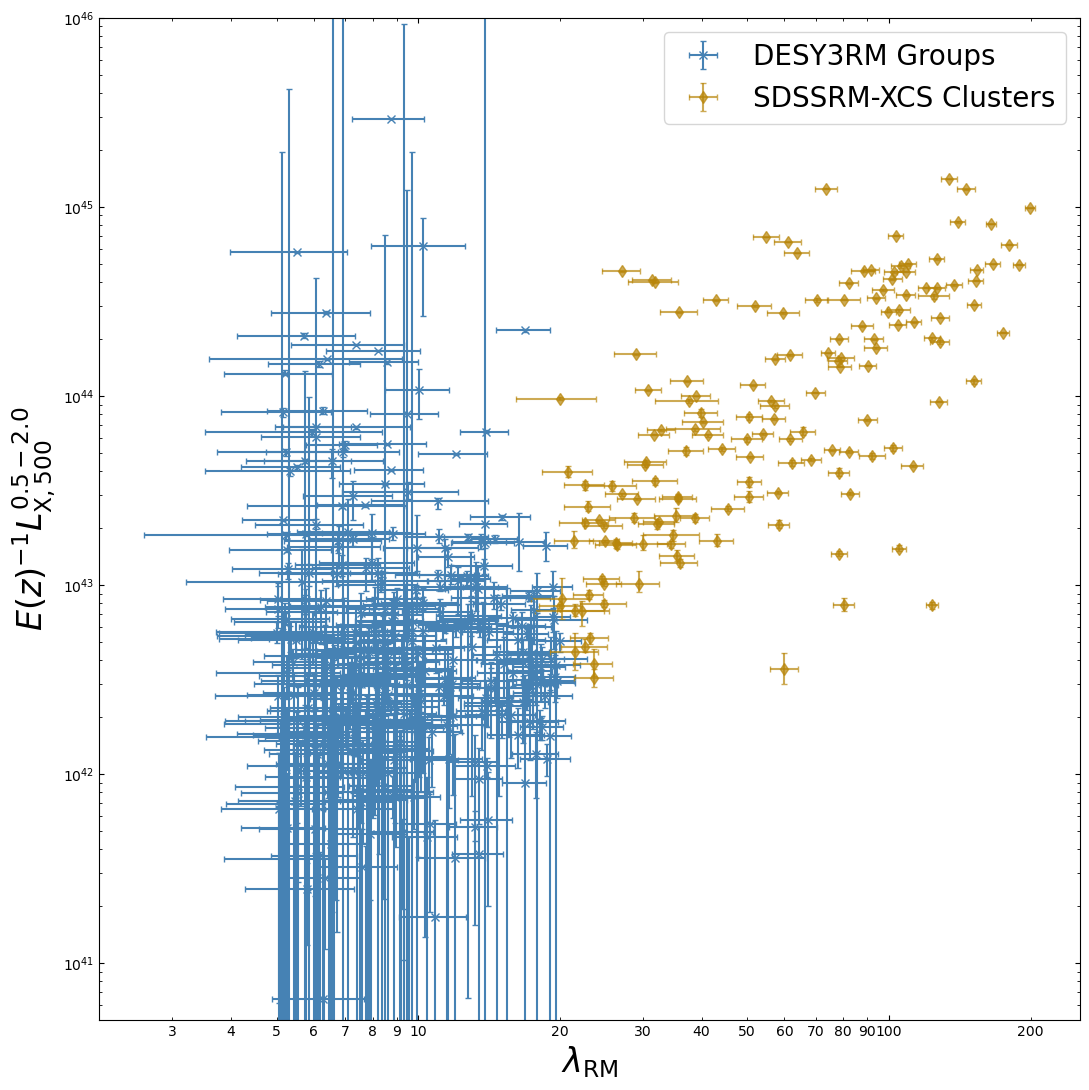

In [22]:
plt.figure(figsize=(11, 11))
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)

desy3_grp_lx500_52 = Quantity(desy3rm_groups_cut[['Lx52_500', 'Lx52_500-','Lx52_500+']].values, 'erg/s')
desy3_grp_rich = Quantity(desy3rm_groups_cut[['richness', 'richness_err', 'richness_err']].values, '')

plt.errorbar(desy3_grp_rich[:, 0].value, desy3_grp_lx500_52[:, 0].value, yerr=desy3_grp_lx500_52[:, 1:].value.T, 
             xerr=desy3_grp_rich[:, 1:].value.T, capsize=2, fmt='x', color='steelblue', label=r'DESY3RM Groups')

# AND NOW THE SDSSRM-XCS SAMPLE AS A COMPARISON 
sdss_clust_lx500_52 = Quantity(sdssrm_xcs_clust[['Lx52_500', 'Lx52_500-','Lx52_500+']].values, 'erg/s')*1e+44
sdss_clust_rich = Quantity(sdssrm_xcs_clust[['richness', 'richness_err', 'richness_err']].values, '')

plt.errorbar(sdss_clust_rich[:, 0].value, sdss_clust_lx500_52[:, 0].value, yerr=sdss_clust_lx500_52[:, 1:].value.T, 
             xerr=sdss_clust_rich[:, 1:].value.T, capsize=2, fmt='d', color='darkgoldenrod', label='SDSSRM-XCS Clusters', 
             alpha=0.7)

plt.ylabel(r"$E(z)^{-1}L^{0.5-2.0}_{\rm{X,500}}$", fontsize=24)
plt.xlabel(r"$\lambda_{\rm{RM}}$", fontsize=24)

plt.xscale("log")
plt.yscale("log")

plt.ylim(5e+40, 1e+46)
# plt.xlim(0.25, 10.8)

plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda inp, _: '{:g}'.format(inp)))
plt.gca().xaxis.set_minor_formatter(FuncFormatter(lambda inp, _: '{:g}'.format(inp)))

plt.legend(fontsize=20)
plt.tight_layout()
plt.savefig(gen_fig_out_path + "desy3-groups_sdssrm-clusters_lx-richness.pdf")
plt.show()

### $L^{\rm{0.5-2.0keV}}_{\rm{X, 500}}$-$T_{\rm{X, 500}}$ with uncertainties $<25\%$

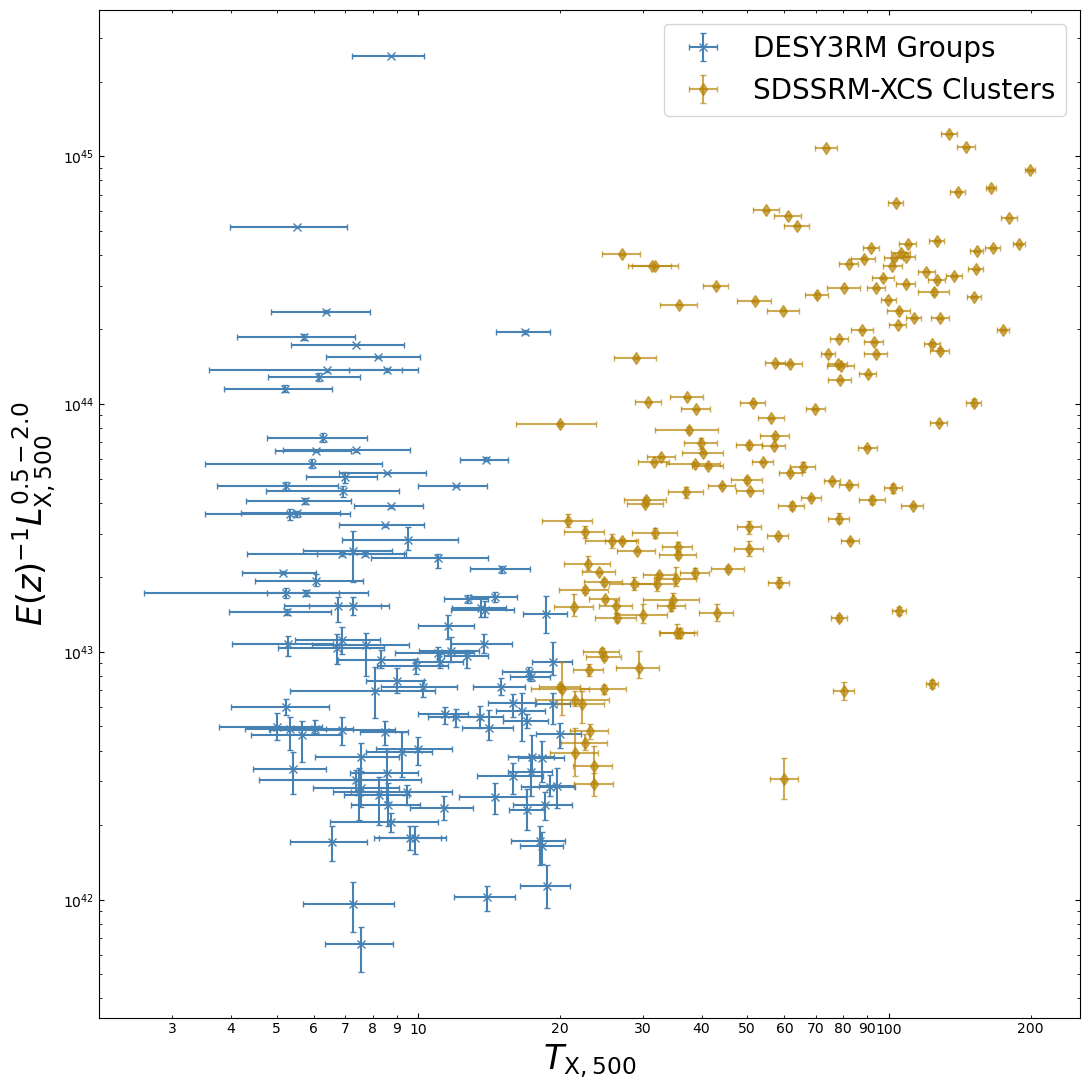

In [21]:
plt.figure(figsize=(11, 11))
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)

desy3_grp_lx500_52 = (Quantity(desy3rm_groups_txerr25_lxerr25[['Lx52_500', 'Lx52_500-','Lx52_500+']].values, 'erg/s')*
                          (desy3rm_groups_txerr25_lxerr25['E'].values[..., None]**-1))
desy3_grp_rich = Quantity(desy3rm_groups_txerr25_lxerr25[['richness', 'richness_err', 'richness_err']].values, '')

plt.errorbar(desy3_grp_rich[:, 0].value, desy3_grp_lx500_52[:, 0].value, yerr=desy3_grp_lx500_52[:, 1:].value.T, 
             xerr=desy3_grp_rich[:, 1:].value.T, capsize=2, fmt='x', color='steelblue', label='DESY3RM Groups')

# AND NOW THE SDSSRM-XCS SAMPLE AS A COMPARISON 
sdss_clust_lx500_52 = (Quantity(sdssrm_xcs_clust[['Lx52_500', 'Lx52_500-','Lx52_500+']].values, 'erg/s')*
                       (sdssrm_xcs_clust['E'].values[..., None]**-1))*1e+44
sdss_clust_rich = Quantity(sdssrm_xcs_clust[['richness', 'richness_err', 'richness_err']].values, 'keV')

plt.errorbar(sdss_clust_rich[:, 0].value, sdss_clust_lx500_52[:, 0].value, yerr=sdss_clust_lx500_52[:, 1:].value.T, 
             xerr=sdss_clust_rich[:, 1:].value.T, capsize=2, fmt='d', color='darkgoldenrod', label='SDSSRM-XCS Clusters', 
             alpha=0.7)

plt.ylabel(r"$E(z)^{-1}L^{0.5-2.0}_{\rm{X,500}}$", fontsize=24)
plt.xlabel(r"$T_{\rm{X,500}}$", fontsize=24)

plt.xscale("log")
plt.yscale("log")

plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda inp, _: '{:g}'.format(inp)))
plt.gca().xaxis.set_minor_formatter(FuncFormatter(lambda inp, _: '{:g}'.format(inp)))

plt.legend(fontsize=20)
plt.tight_layout()
plt.savefig(gen_fig_out_path + "desy3-groups_sdssrm-clusters_lx-richness_lt25percerr.pdf")
plt.show()